In [1]:
# Exponential Smoothing - Consists of flattening Time Series Data
# Importing the necessary packages

import pandas                          as      pd
import numpy                           as      np
import matplotlib.pyplot               as      plt
import statsmodels.tools.eval_measures as      em
from   sklearn.metrics                 import  mean_squared_error
from   statsmodels.tsa.api             import ExponentialSmoothing, SimpleExpSmoothing, Holt
from   IPython.display                 import display
from   pylab                           import rcParams


In [2]:
import sys
import warnings
import itertools
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
%matplotlib inline
from   datetime import datetime

In [3]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Rose.csv', parse_dates = True, index_col = 'Year-Month')

In [4]:
df.head()

,Rose
Year-Month,
1980-01-01,112.0
1980-02-01,118.0
1980-03-01,129.0
1980-04-01,99.0
1980-05-01,116.0


In [5]:
df.tail()

,Rose
Year-Month,
1995-03-01,45.0
1995-04-01,52.0
1995-05-01,28.0
1995-06-01,40.0
1995-07-01,62.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-01 to 1995-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rose    185 non-null    float64
dtypes: float64(1)
memory usage: 2.9 KB


In [7]:
df.describe()

,Rose
count,185.000000
mean,90.394595
std,39.175344
min,28.000000
25%,63.000000
50%,86.000000
75%,112.000000
max,267.000000


In [8]:
# Missing Values check and Treatment
df.isnull().sum()

Rose    2
dtype: int64

In [9]:
# extract out the time-series
Rose_ts = df['Rose']

Text(0, 0.5, 'Rose')

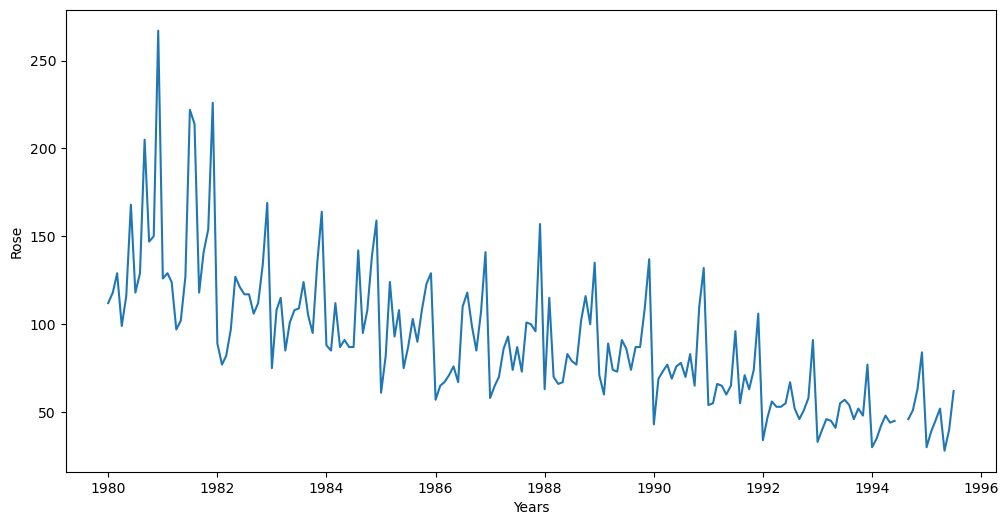

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(Rose_ts)
plt.xlabel('Years')
plt.ylabel('Rose')


In [11]:
df = df.fillna(method='ffill')

In [12]:
df.isnull().sum()


Rose    0
dtype: int64

In [13]:
# To drop duplicate values, if any in the data
duplicates=df.duplicated()
num_duplicates = duplicates.sum()
df.drop_duplicates(inplace=True)

In [14]:
import seaborn as sns

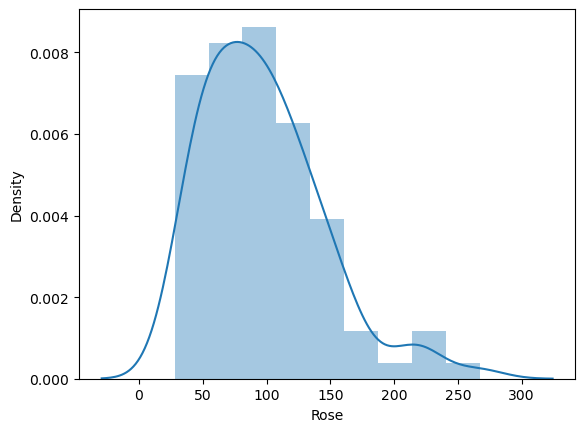

In [15]:
sns.distplot(df['Rose'])
plt.show() 

<Axes: >

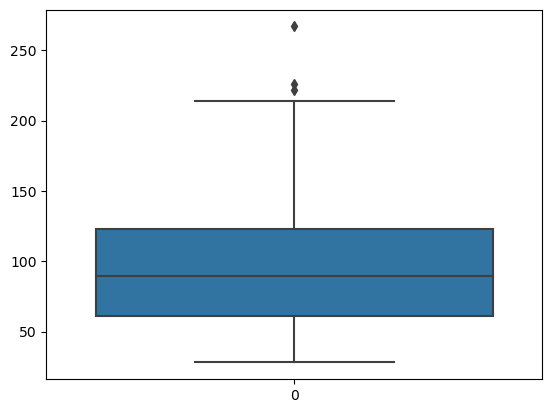

In [16]:
# Univariate Analysis - Boxplot
sns.boxplot(data=df['Rose'])

In [17]:
# extract out the time-series
Rose_ts = df['Rose']

Text(0, 0.5, 'Rose')

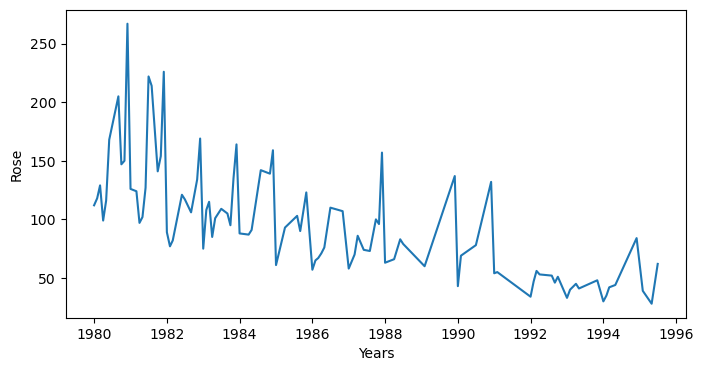

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(Rose_ts)
plt.xlabel('Years')
plt.ylabel('Rose')


In [19]:
# Dickey-Fuller Test - Dicky Fuller Test on the timeseries is run to check for stationarity of data.

# Null Hypothesis H0: Time Series is non-stationary.
# Alternate Hypothesis Ha: Time Series is stationary.
#So Ideally if p-value < 0.05 then null hypothesis: TS is non-stationary is rejected else 
# the TS is non-stationary is failed to be rejected 
from statsmodels.tsa.stattools import adfuller

In [20]:
dftest = adfuller(Rose_ts)#python implementation of dicky fuller test 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -1.157
DF test p-value is 0.6917


In [21]:
# Since p value is greater than 0.05, therefore. we accept the Null Hypothesis and Time Series is non Stationary.

In [22]:
# Differencing the Time Series to make it stationary
Rose_ts = Rose_ts.diff().dropna()

In [23]:
dftest = adfuller(Rose_ts)#python implementation of dicky fuller test 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -8.247
DF test p-value is 0.0000


In [24]:
# Since p value is less than 0.05, therefore. we reject the Null Hypothesis and Time Series is Stationary.

In [25]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Rose.csv', parse_dates= True, index_col = 'Year-Month')


In [26]:
df = df.fillna(method='ffill')

In [27]:
#Separate data into train and test
train = df[df.index < '1991']
test = df[df.index >= '1991']

In [28]:
dftest = adfuller(train['Rose'])#Stationarity check on train time series data 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -2.164
DF test p-value is 0.2195


In [29]:
# Since p value is greater than 0.05, therefore. we accept the Null Hypothesis and Time Series is non Stationary

In [30]:
# Using the log transformed series as there is variance in the data

In [31]:
train_Rose_ts_log = np.log10(train['Rose'])
#Log transformation on the training data to make the time series stationary  

In [32]:
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [33]:
# Simple Exponential Smoothing (Used where there is no trend or seasonality in the data) - ANN Model
# create class
model_SES = SimpleExpSmoothing(train,initialization_method='estimated')

In [34]:
# Fitting the Simple Exponential Smoothing model and asking python to choose the optimal parameters
model_SES_autofit = model_SES.fit(optimized=True)

In [35]:
## Let us check the parameters
model_SES_autofit.params

{'smoothing_level': 0.09874933517484011,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 134.38703609891138,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [36]:
# Using the fitted model on the training set to forecast on the test set
SES_predict = model_SES_autofit.forecast(steps=len(test))
SES_predict

1991-01-01    87.104984
1991-02-01    87.104984
1991-03-01    87.104984
1991-04-01    87.104984
1991-05-01    87.104984
1991-06-01    87.104984
1991-07-01    87.104984
1991-08-01    87.104984
1991-09-01    87.104984
1991-10-01    87.104984
1991-11-01    87.104984
1991-12-01    87.104984
1992-01-01    87.104984
1992-02-01    87.104984
1992-03-01    87.104984
1992-04-01    87.104984
1992-05-01    87.104984
1992-06-01    87.104984
1992-07-01    87.104984
1992-08-01    87.104984
1992-09-01    87.104984
1992-10-01    87.104984
1992-11-01    87.104984
1992-12-01    87.104984
1993-01-01    87.104984
1993-02-01    87.104984
1993-03-01    87.104984
1993-04-01    87.104984
1993-05-01    87.104984
1993-06-01    87.104984
1993-07-01    87.104984
1993-08-01    87.104984
1993-09-01    87.104984
1993-10-01    87.104984
1993-11-01    87.104984
1993-12-01    87.104984
1994-01-01    87.104984
1994-02-01    87.104984
1994-03-01    87.104984
1994-04-01    87.104984
1994-05-01    87.104984
1994-06-01    87

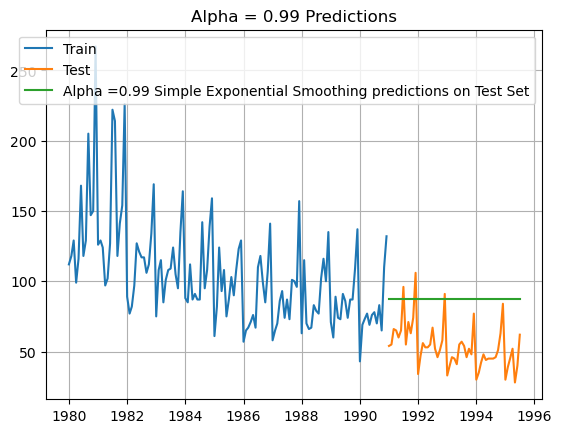

In [37]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha =0.99 Simple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Alpha = 0.99 Predictions');

In [38]:
# Mean Absolute Percentage Error (MAPE) - Function Definition

def MAPE(y_true, y_pred):
    return np.mean((np.abs(y_true-y_pred))/(y_true))*100

In [39]:
print('SES RMSE:',mean_squared_error(test.values,SES_predict.values,squared=False))
#different way to calculate RMSE
print('SES RMSE (calculated using statsmodels):',em.rmse(test.values,SES_predict.values)[0])

SES RMSE: 36.81688991653901
SES RMSE (calculated using statsmodels): 36.81688991653901


In [40]:
resultsDf = pd.DataFrame({'Test RMSE': [em.rmse(test.values,SES_predict.values)[0]]},index=['Alpha=0.99,SES'])
resultsDf

,Test RMSE
"Alpha=0.99,SES",36.81689


In [41]:
# Initializing the Double Exponential Smoothing Model Holt's Model (AAN Model)
# Applicable whwn Data has Trend but no Seasonality 
model_DES = Holt(train,initialization_method='estimated')
# Fitting the model
model_DES = model_DES.fit()

print('')
print('==Holt model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_DES.params)


==Holt model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 1.9086427682180844e-08, 'smoothing_trend': 7.302464353829351e-09, 'smoothing_seasonal': nan, 'damping_trend': nan, 'initial_level': 137.81629861505857, 'initial_trend': -0.4943753249082896, 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [42]:
# Forecasting using this model for the duration of the test set
DES_predict =  model_DES.forecast(len(test))
DES_predict

1991-01-01    72.064380
1991-02-01    71.570005
1991-03-01    71.075630
1991-04-01    70.581254
1991-05-01    70.086879
1991-06-01    69.592504
1991-07-01    69.098128
1991-08-01    68.603753
1991-09-01    68.109378
1991-10-01    67.615002
1991-11-01    67.120627
1991-12-01    66.626252
1992-01-01    66.131877
1992-02-01    65.637501
1992-03-01    65.143126
1992-04-01    64.648751
1992-05-01    64.154375
1992-06-01    63.660000
1992-07-01    63.165625
1992-08-01    62.671249
1992-09-01    62.176874
1992-10-01    61.682499
1992-11-01    61.188123
1992-12-01    60.693748
1993-01-01    60.199373
1993-02-01    59.704997
1993-03-01    59.210622
1993-04-01    58.716247
1993-05-01    58.221871
1993-06-01    57.727496
1993-07-01    57.233121
1993-08-01    56.738745
1993-09-01    56.244370
1993-10-01    55.749995
1993-11-01    55.255619
1993-12-01    54.761244
1994-01-01    54.266869
1994-02-01    53.772493
1994-03-01    53.278118
1994-04-01    52.783743
1994-05-01    52.289367
1994-06-01    51

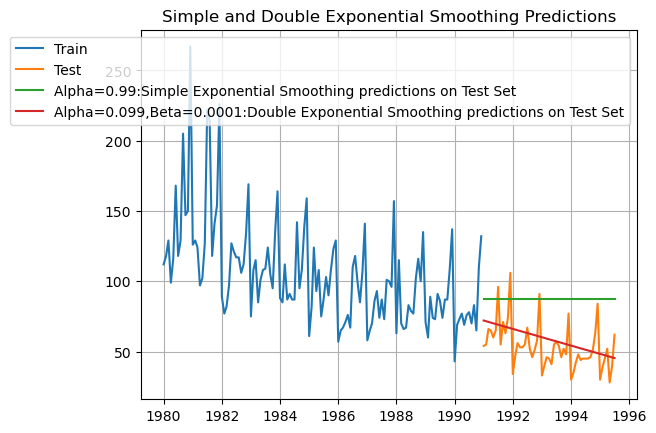

In [43]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=0.99:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.099,Beta=0.0001:Double Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple and Double Exponential Smoothing Predictions');



In [44]:
print('DES RMSE:',mean_squared_error(test.values,DES_predict.values,squared=False))

DES RMSE: 15.276105562580701


In [45]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,DES_predict.values,squared=False)]}
                           ,index=['Alpha=1,Beta=0.0189:DES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",36.816890
"Alpha=1,Beta=0.0189:DES",15.276106


In [46]:
# Initializing the Doubl
seasonal_period=12
model_TES = ExponentialSmoothing(train, trend='additive',seasonal='additive', seasonal_periods= seasonal_period, initialization_method='estimated')
# Fitting the model
model_TES = model_TES.fit()

print('')
print('==Holt Winters model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_TES.params)


==Holt Winters model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 0.08830330642635406, 'smoothing_trend': 6.730635331927582e-05, 'smoothing_seasonal': 0.004455138229351625, 'damping_trend': nan, 'initial_level': 146.88752868155674, 'initial_trend': -0.5492163940406024, 'initial_seasons': array([-31.12207537, -18.81171138, -10.86052241, -21.52235816,
       -12.68359535,  -7.17529564,   2.7456236 ,   8.84900094,
         4.85724354,   2.9520333 ,  21.05004912,  63.29916317]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [47]:
# Forecasting using this model for the duration of the test set
TES_predict =  model_TES.forecast(len(test))
TES_predict

1991-01-01     42.672382
1991-02-01     54.439917
1991-03-01     61.841877
1991-04-01     50.636896
1991-05-01     58.918913
1991-06-01     63.870294
1991-07-01     73.240626
1991-08-01     78.790723
1991-09-01     74.257853
1991-10-01     71.805821
1991-11-01     89.354796
1991-12-01    131.072194
1992-01-01     36.081787
1992-02-01     47.849323
1992-03-01     55.251283
1992-04-01     44.046301
1992-05-01     52.328318
1992-06-01     57.279699
1992-07-01     66.650031
1992-08-01     72.200129
1992-09-01     67.667259
1992-10-01     65.215226
1992-11-01     82.764201
1992-12-01    124.481599
1993-01-01     29.491193
1993-02-01     41.258728
1993-03-01     48.660688
1993-04-01     37.455706
1993-05-01     45.737724
1993-06-01     50.689105
1993-07-01     60.059436
1993-08-01     65.609534
1993-09-01     61.076664
1993-10-01     58.624632
1993-11-01     76.173607
1993-12-01    117.891005
1994-01-01     22.900598
1994-02-01     34.668134
1994-03-01     42.070093
1994-04-01     30.865112


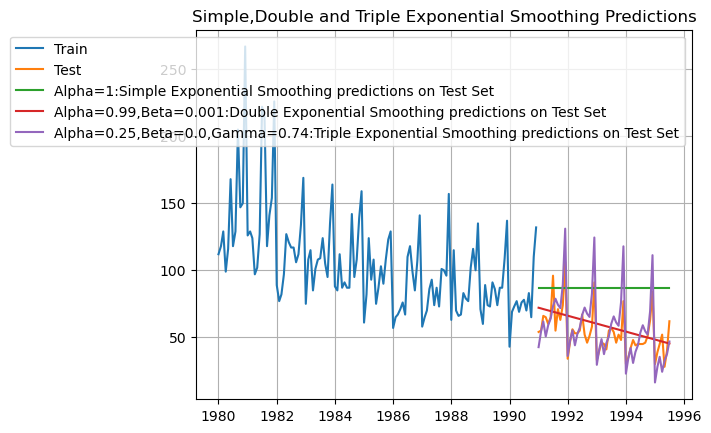

In [48]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=1:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.99,Beta=0.001:Double Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict, label='Alpha=0.25,Beta=0.0,Gamma=0.74:Triple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple,Double and Triple Exponential Smoothing Predictions');

In [49]:
print('TES RMSE:',mean_squared_error(test.values,TES_predict.values,squared=False))

TES RMSE: 14.280860283342175


In [50]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,TES_predict.values,squared=False)]}
                           ,index=['Alpha=0.25,Beta=0.0,Gamma=0.74:TES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",36.816890
"Alpha=1,Beta=0.0189:DES",15.276106
"Alpha=0.25,Beta=0.0,Gamma=0.74:TES",14.280860


In [51]:
# Holt Winters - AAM Method
# Initializing the Double Exponential Smoothing Model
seasonal_period=12
model_TES_am = ExponentialSmoothing(train,trend='add',seasonal='multiplicative',seasonal_periods= seasonal_period, initialization_method='estimated')
# Fitting the model
model_TES_am = model_TES_am.fit()

print('')
print('==Holt Winters model Exponential Smoothing Estimated Parameters ==')
print('')
print(model_TES_am.params)


==Holt Winters model Exponential Smoothing Estimated Parameters ==

{'smoothing_level': 0.07132109562890512, 'smoothing_trend': 0.04553831096563722, 'smoothing_seasonal': 8.356711212063695e-07, 'damping_trend': nan, 'initial_level': 134.25655591779326, 'initial_trend': -0.8038265942903572, 'initial_seasons': array([0.83746068, 0.94985307, 1.03812083, 0.90732186, 1.02043162,
       1.11131741, 1.22228039, 1.30104211, 1.23132915, 1.20610008,
       1.40577823, 1.93832412]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [52]:
# Forecasting using this model for the duration of the test set
TES_predict_am =  model_TES_am.forecast(len(test))
TES_predict_am

1991-01-01     56.334597
1991-02-01     63.692059
1991-03-01     69.388935
1991-04-01     60.452304
1991-05-01     67.770362
1991-06-01     73.568837
1991-07-01     80.653311
1991-08-01     85.572391
1991-09-01     80.724066
1991-10-01     78.812306
1991-11-01     91.559770
1991-12-01    125.830690
1992-01-01     54.186661
1992-02-01     61.255856
1992-03-01     66.726340
1992-04-01     58.125185
1992-05-01     65.153138
1992-06-01     70.718509
1992-07-01     77.518382
1992-08-01     82.235452
1992-09-01     77.565928
1992-10-01     75.718876
1992-11-01     87.954200
1992-12-01    120.859237
1993-01-01     52.038725
1993-02-01     58.819652
1993-03-01     64.063746
1993-04-01     55.798066
1993-05-01     62.535913
1993-06-01     67.868180
1993-07-01     74.383453
1993-08-01     78.898513
1993-09-01     74.407789
1993-10-01     72.625445
1993-11-01     84.348631
1993-12-01    115.887785
1994-01-01     49.890789
1994-02-01     56.383449
1994-03-01     61.401152
1994-04-01     53.470947


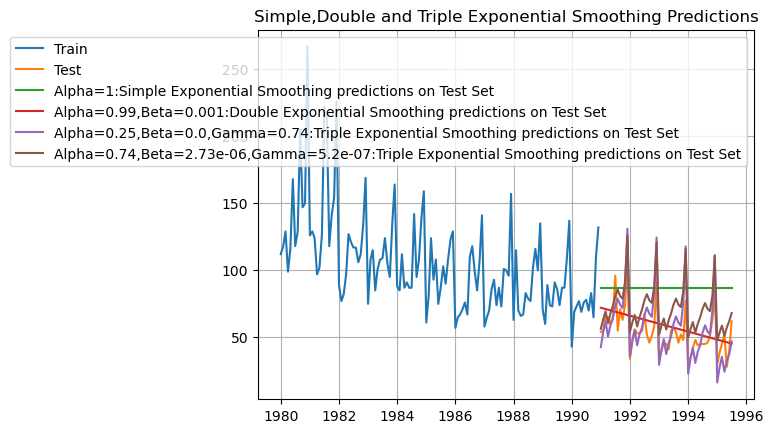

In [53]:
## Plotting the Training data, Test data and the forecasted values

plt.plot(train, label='Train')
plt.plot(test, label='Test')

plt.plot(SES_predict, label='Alpha=1:Simple Exponential Smoothing predictions on Test Set')
plt.plot(DES_predict, label='Alpha=0.99,Beta=0.001:Double Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict, label='Alpha=0.25,Beta=0.0,Gamma=0.74:Triple Exponential Smoothing predictions on Test Set')
plt.plot(TES_predict_am, label='Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07:Triple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Simple,Double and Triple Exponential Smoothing Predictions');

In [54]:
print('TES_am RMSE:',mean_squared_error(test.values,TES_predict_am.values,squared=False))

TES_am RMSE: 20.21695692215922


In [55]:
resultsDf_temp = pd.DataFrame({'Test RMSE': [mean_squared_error(test.values,TES_predict_am.values,squared=False)]}
                           ,index=['Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07,Gamma=0:TES'])

resultsDf = pd.concat([resultsDf, resultsDf_temp])
resultsDf

,Test RMSE
"Alpha=0.99,SES",36.816890
"Alpha=1,Beta=0.0189:DES",15.276106
"Alpha=0.25,Beta=0.0,Gamma=0.74:TES",14.280860
"Alpha=0.74,Beta=2.73e-06,Gamma=5.2e-07,Gamma=0:TES",20.216957


In [56]:
print(train.shape)
print(test.shape)

(132, 1)
(55, 1)


In [57]:
# Model 1 Linear Regression
train_time = [i+1 for i in range(len(train))]
test_time = [i+127 for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Test Time instance 
 [127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181]


In [58]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [59]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data')
display(LinearRegression_train.head())
print('Last few rows of Training Data')
display(LinearRegression_train.tail())
print('First few rows of Test Data')
display(LinearRegression_test.head())
print('Last few rows of Test Data')
display(LinearRegression_test.tail())

First few rows of Training Data


,Rose,time
Year-Month,,
1980-01-01,112.0,1
1980-02-01,118.0,2
1980-03-01,129.0,3
1980-04-01,99.0,4
1980-05-01,116.0,5


Last few rows of Training Data


,Rose,time
Year-Month,,
1990-08-01,70.0,128
1990-09-01,83.0,129
1990-10-01,65.0,130
1990-11-01,110.0,131
1990-12-01,132.0,132


First few rows of Test Data


,Rose,time
Year-Month,,
1991-01-01,54.0,127
1991-02-01,55.0,128
1991-03-01,66.0,129
1991-04-01,65.0,130
1991-05-01,60.0,131


Last few rows of Test Data


,Rose,time
Year-Month,,
1995-03-01,45.0,177
1995-04-01,52.0,178
1995-05-01,28.0,179
1995-06-01,40.0,180
1995-07-01,62.0,181


In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lr = LinearRegression()

In [62]:
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Rose'])

LinearRegression()

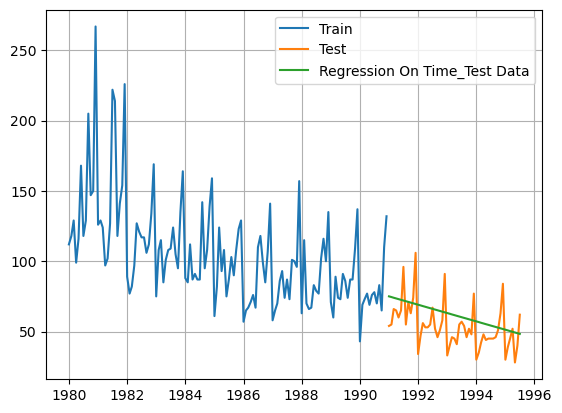

In [63]:
train_predictions_model1         = lr.predict(LinearRegression_train[['time']])
LinearRegression_train['RegOnTime'] = train_predictions_model1

test_predictions_model1         = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model1

plt.plot( train['Rose'], label='Train')
plt.plot(test['Rose'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')

plt.legend(loc='best')
plt.grid();


In [64]:
from sklearn import metrics

In [65]:
# Model Evaluation
rmse_model1_test = metrics.mean_squared_error(test['Rose'],test_predictions_model1,squared=False)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f " %(rmse_model1_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 16.465 


In [66]:
resultsDf = pd.DataFrame({'Test RMSE': [rmse_model1_test]},index=['RegressionOnTime'])
resultsDf

,Test RMSE
RegressionOnTime,16.464804


In [67]:
# Model 2 - Naive Approach (yt+1 = yt)
NaiveModel_train = train.copy()
NaiveModel_test = test.copy()

In [68]:
train.tail()

,Rose
Year-Month,
1990-08-01,70.0
1990-09-01,83.0
1990-10-01,65.0
1990-11-01,110.0
1990-12-01,132.0


In [69]:
NaiveModel_test['naive'] = np.asarray(train['Rose'])[len(np.asarray(train['Rose']))-1]
NaiveModel_test['naive'].head()

Year-Month
1991-01-01    132.0
1991-02-01    132.0
1991-03-01    132.0
1991-04-01    132.0
1991-05-01    132.0
Name: naive, dtype: float64

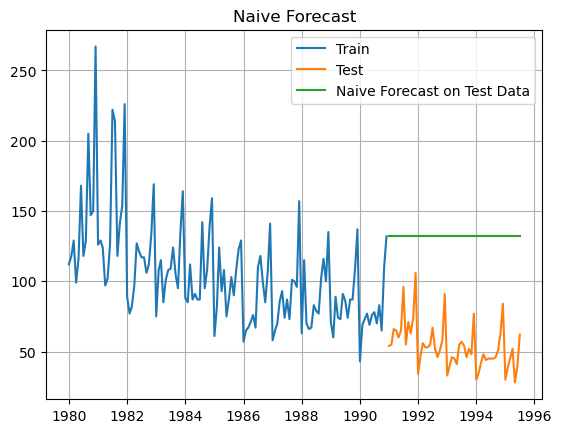

In [70]:
plt.plot(NaiveModel_train['Rose'], label='Train')
plt.plot(test['Rose'], label='Test')

plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')

plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid();

In [71]:
# Model Evaluation
rmse_model2_test = metrics.mean_squared_error(test['Rose'],NaiveModel_test['naive'],squared=False)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f" %(rmse_model2_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 79.739


In [72]:
resultsDf_2 = pd.DataFrame({'Test RMSE': [rmse_model2_test]},index=['NaiveModel'])

resultsDf = pd.concat([resultsDf, resultsDf_2])
resultsDf

,Test RMSE
RegressionOnTime,16.464804
NaiveModel,79.738550


In [73]:
# Model 3 - Simple Average
SimpleAverage_train = train.copy()
SimpleAverage_test = test.copy()

In [74]:
SimpleAverage_test['mean_forecast'] = train['Rose'].mean()
SimpleAverage_test.head()

,Rose,mean_forecast
Year-Month,,
1991-01-01,54.0,104.939394
1991-02-01,55.0,104.939394
1991-03-01,66.0,104.939394
1991-04-01,65.0,104.939394
1991-05-01,60.0,104.939394


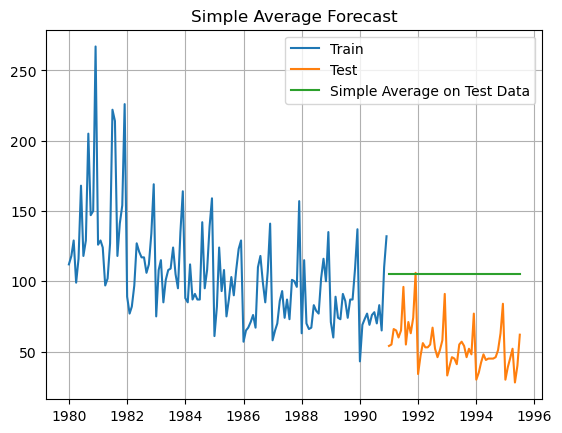

In [75]:
plt.plot(SimpleAverage_train['Rose'], label='Train')
plt.plot(SimpleAverage_test['Rose'], label='Test')

plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')

plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid();

In [76]:
# Model Evaluation
rmse_model3_test = metrics.mean_squared_error(test['Rose'],SimpleAverage_test['mean_forecast'],squared=False)
print("For Simple Average forecast on the Test Data,  RMSE is %3.3f" %(rmse_model3_test))

For Simple Average forecast on the Test Data,  RMSE is 53.481


In [77]:
resultsDf_3 = pd.DataFrame({'Test RMSE': [rmse_model3_test]}
                           ,index=['SimpleAverageModel'])

resultsDf = pd.concat([resultsDf, resultsDf_3])
resultsDf

,Test RMSE
RegressionOnTime,16.464804
NaiveModel,79.738550
SimpleAverageModel,53.480857


In [78]:
df=pd.read_csv(r'C:\Users\Anmol\Desktop\Rose.csv')

In [79]:
df = df.fillna(method='ffill')

In [80]:
df.isnull().sum()

Year-Month    0
Rose          0
dtype: int64

In [81]:
# Code to convert/split the data as per frequency
dates = pd.date_range(start='1980-01-01', freq='MS', periods=len(df))

In [82]:
import calendar
df['Month'] = dates.month
df['Month'] = df['Month'].apply(lambda x: calendar.month_abbr[x]) #spltting into english month names 
df['Year'] = dates.year

In [83]:
df.set_index(dates, inplace=True)

In [84]:
df.head(5)

,Year-Month,Rose,Month,Year
1980-01-01,1980-01,112.0,Jan,1980
1980-02-01,1980-02,118.0,Feb,1980
1980-03-01,1980-03,129.0,Mar,1980
1980-04-01,1980-04,99.0,Apr,1980
1980-05-01,1980-05,116.0,May,1980


In [85]:
# Code to extract the time-series and plot it, and provide the inferences accordingly.
# extract out the time-series
Rose_ts = df['Rose']

Text(0, 0.5, 'Rose')

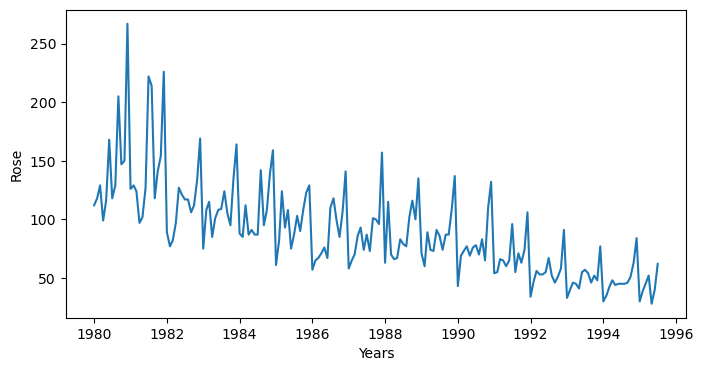

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(Rose_ts)
plt.xlabel('Years')
plt.ylabel('Rose')

In [87]:
# Basic Bivariate Analysis
monthly_sales_data = pd.pivot_table(df, values = "Rose", columns = "Year", index = "Month")
monthly_sales_data

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995
Month,,,,,,,,,,,,,,,,
Apr,99.0,97.0,97.0,85.0,87.0,93.0,71.0,86.0,66.0,74.0,77.0,65.0,53.0,45.0,48.0,52.0
Aug,129.0,214.0,117.0,124.0,142.0,103.0,118.0,73.0,77.0,74.0,70.0,55.0,52.0,54.0,45.0,NaN
Dec,267.0,226.0,169.0,164.0,159.0,129.0,141.0,157.0,135.0,137.0,132.0,106.0,91.0,77.0,84.0,NaN
Feb,118.0,129.0,77.0,108.0,85.0,82.0,65.0,65.0,115.0,60.0,69.0,55.0,47.0,40.0,35.0,39.0
Jan,112.0,126.0,89.0,75.0,88.0,61.0,57.0,58.0,63.0,71.0,43.0,54.0,34.0,33.0,30.0,30.0
Jul,118.0,222.0,117.0,109.0,87.0,87.0,110.0,87.0,79.0,86.0,78.0,96.0,67.0,57.0,45.0,62.0
Jun,168.0,127.0,121.0,108.0,87.0,75.0,67.0,74.0,83.0,91.0,76.0,65.0,55.0,55.0,45.0,40.0
Mar,129.0,124.0,82.0,115.0,112.0,124.0,67.0,70.0,70.0,89.0,73.0,66.0,56.0,46.0,42.0,45.0
May,116.0,102.0,127.0,101.0,91.0,108.0,76.0,93.0,67.0,73.0,69.0,60.0,53.0,41.0,44.0,28.0


In [88]:
monthly_sales_data = monthly_sales_data.reindex(index = ['Jan','Feb','Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
monthly_sales_data

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995
Month,,,,,,,,,,,,,,,,
Jan,112.0,126.0,89.0,75.0,88.0,61.0,57.0,58.0,63.0,71.0,43.0,54.0,34.0,33.0,30.0,30.0
Feb,118.0,129.0,77.0,108.0,85.0,82.0,65.0,65.0,115.0,60.0,69.0,55.0,47.0,40.0,35.0,39.0
Mar,129.0,124.0,82.0,115.0,112.0,124.0,67.0,70.0,70.0,89.0,73.0,66.0,56.0,46.0,42.0,45.0
Apr,99.0,97.0,97.0,85.0,87.0,93.0,71.0,86.0,66.0,74.0,77.0,65.0,53.0,45.0,48.0,52.0
May,116.0,102.0,127.0,101.0,91.0,108.0,76.0,93.0,67.0,73.0,69.0,60.0,53.0,41.0,44.0,28.0
Jun,168.0,127.0,121.0,108.0,87.0,75.0,67.0,74.0,83.0,91.0,76.0,65.0,55.0,55.0,45.0,40.0
Jul,118.0,222.0,117.0,109.0,87.0,87.0,110.0,87.0,79.0,86.0,78.0,96.0,67.0,57.0,45.0,62.0
Aug,129.0,214.0,117.0,124.0,142.0,103.0,118.0,73.0,77.0,74.0,70.0,55.0,52.0,54.0,45.0,NaN
Sep,205.0,118.0,106.0,105.0,95.0,90.0,99.0,101.0,102.0,87.0,83.0,71.0,46.0,46.0,46.0,NaN


<Axes: xlabel='Month'>

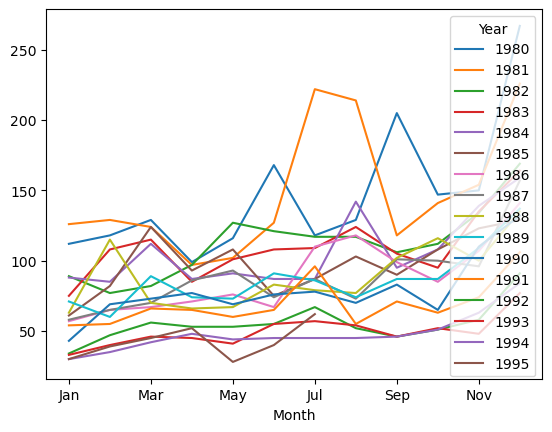

In [89]:
monthly_sales_data.plot()

In [90]:
yearly_sales_data = pd.pivot_table(df, values = "Rose", columns = "Month", index = "Year")
yearly_sales_data = yearly_sales_data[['Jan','Feb','Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']]
yearly_sales_data

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
1980,112.0,118.0,129.0,99.0,116.0,168.0,118.0,129.0,205.0,147.0,150.0,267.0
1981,126.0,129.0,124.0,97.0,102.0,127.0,222.0,214.0,118.0,141.0,154.0,226.0
1982,89.0,77.0,82.0,97.0,127.0,121.0,117.0,117.0,106.0,112.0,134.0,169.0
1983,75.0,108.0,115.0,85.0,101.0,108.0,109.0,124.0,105.0,95.0,135.0,164.0
1984,88.0,85.0,112.0,87.0,91.0,87.0,87.0,142.0,95.0,108.0,139.0,159.0
1985,61.0,82.0,124.0,93.0,108.0,75.0,87.0,103.0,90.0,108.0,123.0,129.0
1986,57.0,65.0,67.0,71.0,76.0,67.0,110.0,118.0,99.0,85.0,107.0,141.0
1987,58.0,65.0,70.0,86.0,93.0,74.0,87.0,73.0,101.0,100.0,96.0,157.0
1988,63.0,115.0,70.0,66.0,67.0,83.0,79.0,77.0,102.0,116.0,100.0,135.0


<Axes: xlabel='Year'>

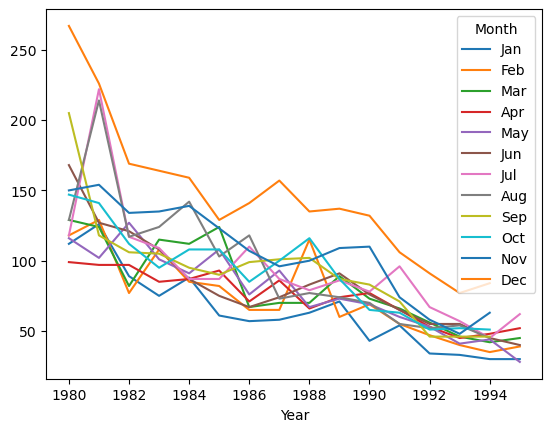

In [91]:
yearly_sales_data.plot()

<Axes: >

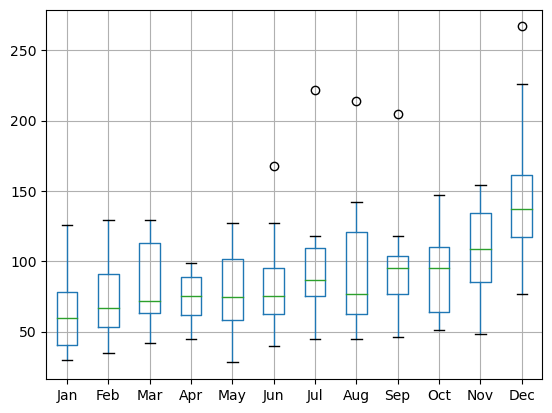

In [92]:
yearly_sales_data.boxplot()

In [93]:
# Time Series Decomposition
decomposition = sm.tsa.seasonal_decompose(Rose_ts, model='additive')

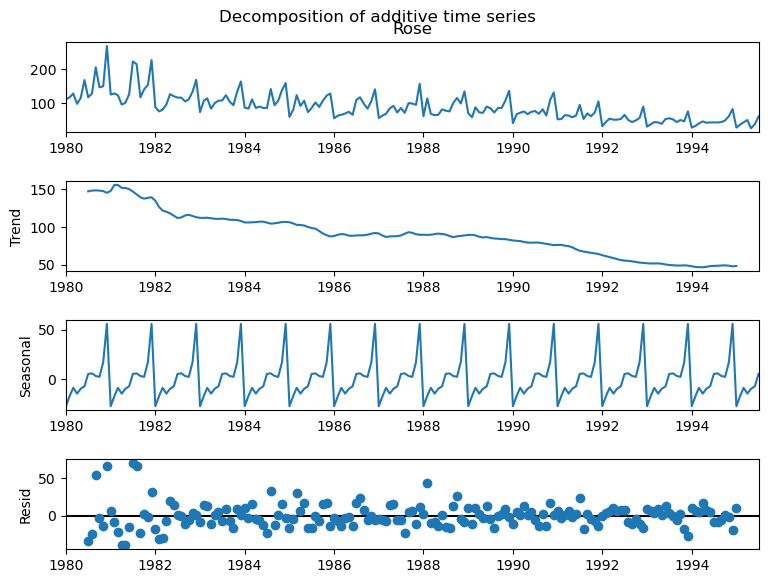

In [94]:
fig = decomposition.plot()
fig.set_figwidth(8)
fig.set_figheight(6)
fig.suptitle('Decomposition of additive time series')
plt.show()

In [95]:
# Time Series Decomposition
decomposition = sm.tsa.seasonal_decompose(Rose_ts, model='multiplicative')

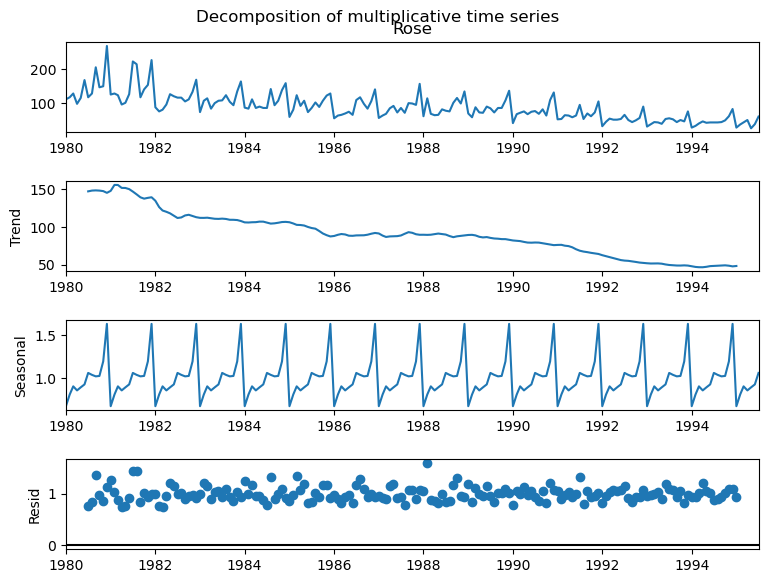

In [96]:
fig = decomposition.plot()
fig.set_figwidth(8)
fig.set_figheight(6)
fig.suptitle('Decomposition of multiplicative time series')
plt.show()

In [97]:
#Separate data into train and test
df['date'] = df.index
train = df[df.index < '1990-01-01']
test = df[df.index >= '1990-01-01']

In [98]:
dftest = adfuller(train['Rose'])#Stationarity check on train time series data 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -2.192
DF test p-value is 0.2091


Text(0, 0.5, 'Rose')

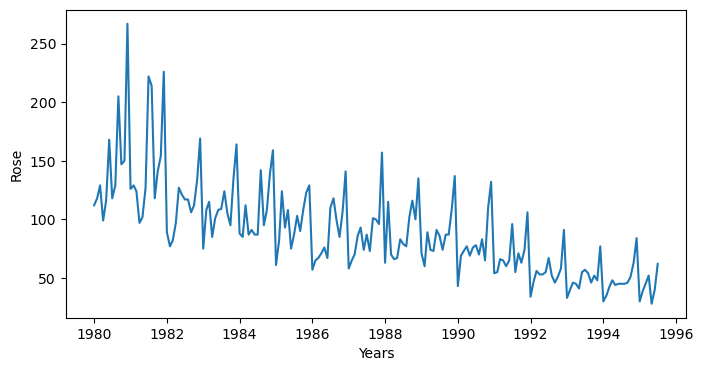

In [99]:
# Non differenced full data Time series
plt.figure(figsize=(8, 4))
plt.plot(Rose_ts)
plt.xlabel('Years')
plt.ylabel('Rose')

Text(0, 0.5, 'Rose')

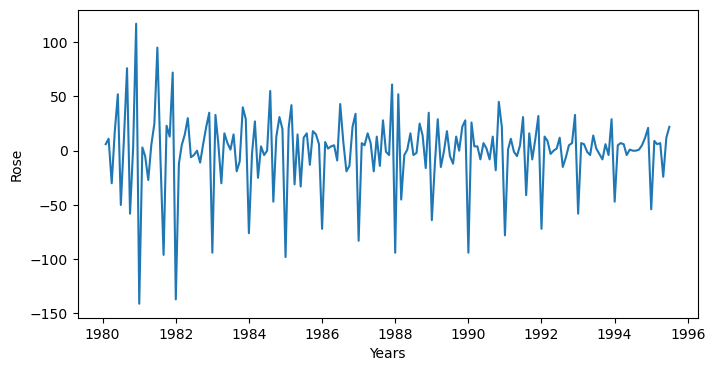

In [100]:
# Performing differencing ( d=1 ) as the data is non-stationary
plt.figure(figsize=(8, 4))
plt.plot(Rose_ts.diff(periods=1))
plt.xlabel('Years')
plt.ylabel('Rose')

Text(0, 0.5, 'Log (Rose)')

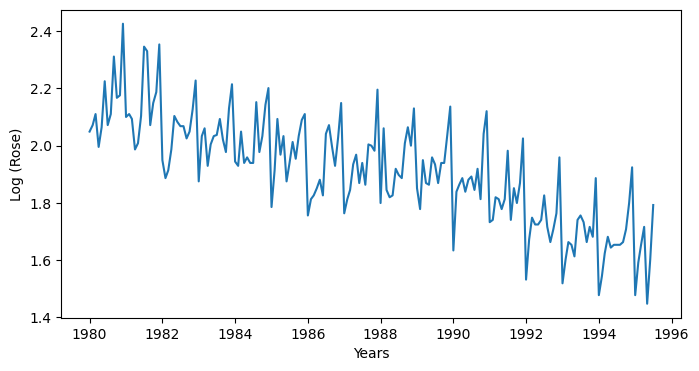

In [101]:
# We observe seasonality even after differencing. Meaning the variance in the data seemss to be increasing
# This suggests a log transformation of the data
plt.figure(figsize=(8, 4))
plt.plot(np.log10(Rose_ts))
plt.xlabel('Years')
plt.ylabel('Log (Rose)')

In [102]:
# AR Model

# Define the p parameter to take any value between 0 and 2
p= range(1,4)


In [103]:
# MA Model

# Define the q parameter to take any value between 0 and 2
q = range(1, 4)


In [104]:
d= range(0,2)

#Generate all different combinations of p with d=0 and q=0 triplets for AR model building
pdq_ar = list(itertools.product(p, range(1), range(1)))

#Generate all different combinations of p,q with d=0 triplets for ARMA model building
pdq_arma = list(itertools.product(p, range(1),q))

#Generate all different combinations of p, d and q triplets for ARIMA model building 
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal P,D,Q triplets for SARIMA model building
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

In [105]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [106]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [107]:
pdq

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [108]:
seasonal_pdq
# as it seems to have 12 month seasonality as confirmned from above 

[(1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 0, 3, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 0, 3, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (3, 0, 1, 12),
 (3, 0, 2, 12),
 (3, 0, 3, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12)]

In [109]:
# Train test split
#Separate data into train and test
df['date'] = df.index
train = df[df.index < '1990-01-01']
test = df[df.index >= '1990-01-01']


In [110]:
dftest = adfuller(train['Rose'])#Stationarity check on train time series data 
dftest
print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is -2.192
DF test p-value is 0.2091


In [111]:
# Using the log transformed series as there is variance in the data
train_Rose_ts_log = np.log10(train['Rose'])
#Log transformation on the training data to make the time series stationary as we did with full data 

In [112]:
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [113]:
# AR Model building to estimate best 'p' ( Lowest AIC Approach )

# Creating an empty Dataframe with column names only
AR_AIC = pd.DataFrame(columns=['param', 'AIC'])
AR_AIC

,param,AIC


In [114]:
from statsmodels.tsa.arima.model import ARIMA

for param in pdq_ar:
    ARIMA_model = ARIMA(train_Rose_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    AR_AIC = AR_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 0) - AIC:-165.28846941411967
ARIMA(2, 0, 0) - AIC:-164.40481361337487
ARIMA(3, 0, 0) - AIC:-167.58890192313498


In [115]:
# Building AR model with best 'p' parameter
best_model = ARIMA(train_Rose_ts_log,order = (1,0,0))#p=1 with lowest AIC 
best_results = best_model.fit()

In [116]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                   Rose   No. Observations:                  120
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  85.644
Date:                Sun, 28 Jan 2024   AIC                           -165.288
Time:                        10:44:26   BIC                           -156.926
Sample:                    01-01-1980   HQIC                          -161.892
                         - 12-01-1989                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0117      0.022     89.517      0.000       1.968       2.056
ar.L1          0.4356      0.084      5.210      0.000       0.272       0.599
sigma2         0.0140      0.002      8.795      0.0

In [117]:
# Calculating RMSE for best AR model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [118]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [119]:
# Extract the predicted and true values of our time series
Sparkling_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Rose_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [120]:
# Compute the root mean square error
mse = ((testCopy1['Rose'] - testCopy1['Rose_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 48.891


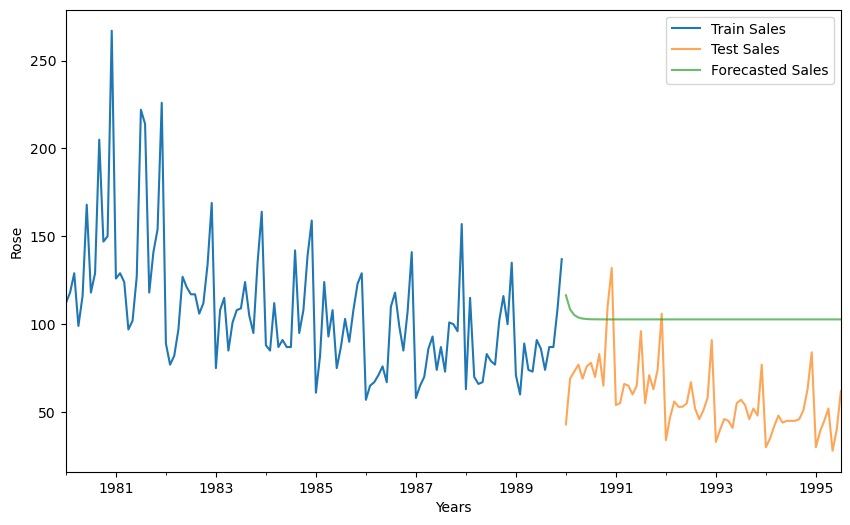

In [121]:
axis = train['Rose'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Rose'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Rose_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()
plt.close()

In [122]:
resultsDf = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best AR Model : ARIMA(2,0,0)'])

resultsDf

,RMSE
"Best AR Model : ARIMA(2,0,0)",48.891405


In [123]:
# ARMA Model building to estimate best 'p' , 'q' ( Lowest AIC Approach )
# Creating an empty Dataframe with column names only
ARMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARMA_AIC

,param,AIC


In [124]:
from statsmodels.tsa.arima.model import ARIMA

for param in pdq_arma:
    ARIMA_model = ARIMA(train_Rose_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARMA_AIC =ARMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 1) - AIC:-168.5785879380458
ARIMA(1, 0, 2) - AIC:-171.99013941595035
ARIMA(1, 0, 3) - AIC:-165.8879697166003
ARIMA(2, 0, 1) - AIC:-171.25138307850006
ARIMA(2, 0, 2) - AIC:-171.09288189974595
ARIMA(2, 0, 3) - AIC:-169.26278049644083
ARIMA(3, 0, 1) - AIC:-165.83317382392357
ARIMA(3, 0, 2) - AIC:-169.29568834732765
ARIMA(3, 0, 3) - AIC:-167.10823798573932


In [125]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARMA_AIC.sort_values(by='AIC',ascending=True).head()

,param,AIC
1,"(1, 0, 2)",-171.990139
3,"(2, 0, 1)",-171.251383
4,"(2, 0, 2)",-171.092882
7,"(3, 0, 2)",-169.295688
5,"(2, 0, 3)",-169.262780


In [126]:
# Building ARMA model with best p,q parameter
best_model = ARIMA(train_Rose_ts_log,order = (1,0,2))
best_results = best_model.fit()

In [127]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                   Rose   No. Observations:                  120
Model:                 ARIMA(1, 0, 2)   Log Likelihood                  90.995
Date:                Sun, 28 Jan 2024   AIC                           -171.990
Time:                        10:45:22   BIC                           -158.053
Sample:                    01-01-1980   HQIC                          -166.330
                         - 12-01-1989                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0225      0.072     28.105      0.000       1.881       2.164
ar.L1          0.9839      0.029     33.915      0.000       0.927       1.041
ma.L1         -0.6616      0.097     -6.797      0.0

In [128]:
# Calculating RMSE for best MA model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [129]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [130]:
# Extract the predicted and true values of our time series
Rose_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Rose_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [131]:
# Compute the root mean square error
mse = ((testCopy1['Rose'] - testCopy1['Rose_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 44.794


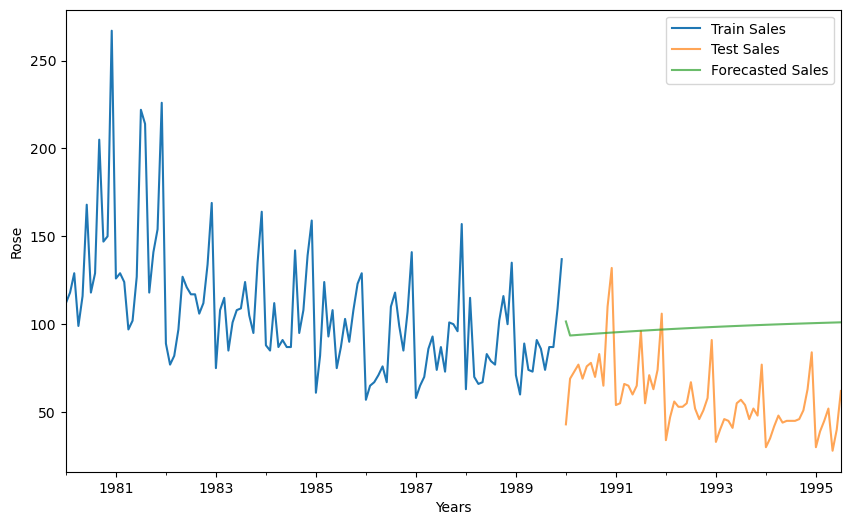

In [132]:
axis = train['Rose'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Rose'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Rose_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()
plt.close()

In [133]:
resultsDf1 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best ARMA Model : ARIMA(3,0,3)'])

resultsDf1

pd.concat([resultsDf,resultsDf1])

,RMSE
"Best AR Model : ARIMA(2,0,0)",48.891405
"Best ARMA Model : ARIMA(3,0,3)",44.794385


In [134]:
# ARIMA Model building to estimate best 'p' , 'd' , 'q' paramters ( Lowest AIC Approach )
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [135]:
from statsmodels.tsa.arima.model import ARIMA



In [136]:
for param in pdq:
    ARIMA_model = ARIMA(train_Rose_ts_log,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = ARIMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(1, 0, 1) - AIC:-168.5785879380458
ARIMA(1, 0, 2) - AIC:-171.99013941595035
ARIMA(1, 0, 3) - AIC:-165.8879697166003
ARIMA(1, 1, 1) - AIC:-172.21729509836615
ARIMA(1, 1, 2) - AIC:-172.0808530039646
ARIMA(1, 1, 3) - AIC:-170.25407431983413
ARIMA(2, 0, 1) - AIC:-171.25138307850006
ARIMA(2, 0, 2) - AIC:-171.09288189974595
ARIMA(2, 0, 3) - AIC:-169.26278049644083
ARIMA(2, 1, 1) - AIC:-170.7925727832362
ARIMA(2, 1, 2) - AIC:-170.29184076309437
ARIMA(2, 1, 3) - AIC:-168.34600359801144
ARIMA(3, 0, 1) - AIC:-165.83317382392357
ARIMA(3, 0, 2) - AIC:-169.29568834732765
ARIMA(3, 0, 3) - AIC:-167.10823798573932
ARIMA(3, 1, 1) - AIC:-169.41991433315764
ARIMA(3, 1, 2) - AIC:-168.43791530450144
ARIMA(3, 1, 3) - AIC:-170.53744103990658


In [137]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True).head()

,param,AIC
3,"(1, 1, 1)",-172.217295
4,"(1, 1, 2)",-172.080853
1,"(1, 0, 2)",-171.990139
6,"(2, 0, 1)",-171.251383
7,"(2, 0, 2)",-171.092882


In [138]:
# Building ARIMA model with best parameters p,d,q

best_model = ARIMA(train_Rose_ts_log,order = (1,1,1))
best_results = best_model.fit()

In [139]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:                   Rose   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  89.109
Date:                Sun, 28 Jan 2024   AIC                           -172.217
Time:                        10:46:07   BIC                           -163.880
Sample:                    01-01-1980   HQIC                          -168.832
                         - 12-01-1989                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2149      0.087      2.468      0.014       0.044       0.386
ma.L1         -0.9198      0.055    -16.851      0.000      -1.027      -0.813
sigma2         0.0129      0.002      7.428      0.0

In [140]:
# Calculating RMSE for best ARIMA model
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [141]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)#forecasting values 

In [142]:
# Extract the predicted and true values of our time series
Rose_sales_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['Rose_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [143]:
# Compute the root mean square error
mse = ((testCopy1['Rose'] - testCopy1['Rose_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 37.961


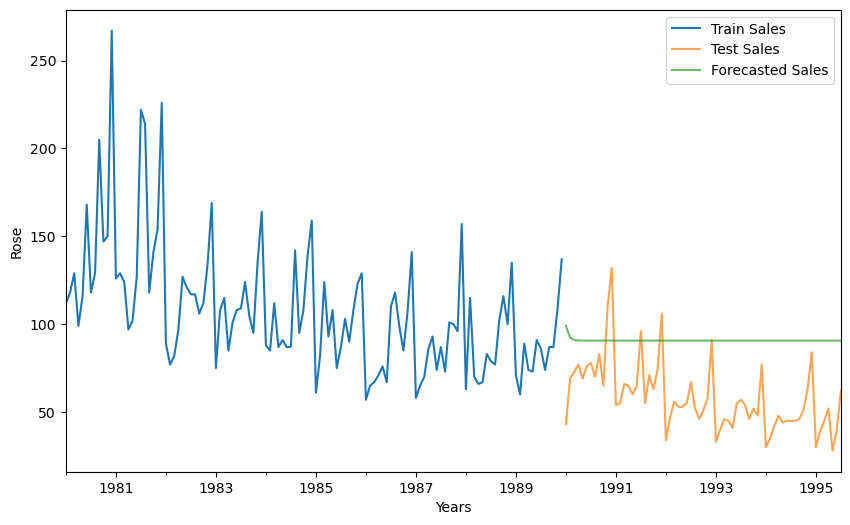

In [144]:
axis = train['Rose'].plot(label='Train Sales', figsize=(10, 6))
testCopy1['Rose'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['Rose_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()
plt.close()

In [145]:
resultsDf2 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best ARIMA Model : ARIMA(3,0,3)'])

resultsDf2

pd.concat([resultsDf,resultsDf1,resultsDf2])

,RMSE
"Best AR Model : ARIMA(2,0,0)",48.891405
"Best ARMA Model : ARIMA(3,0,3)",44.794385
"Best ARIMA Model : ARIMA(3,0,3)",37.961345


In [146]:
# SARIMA Model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


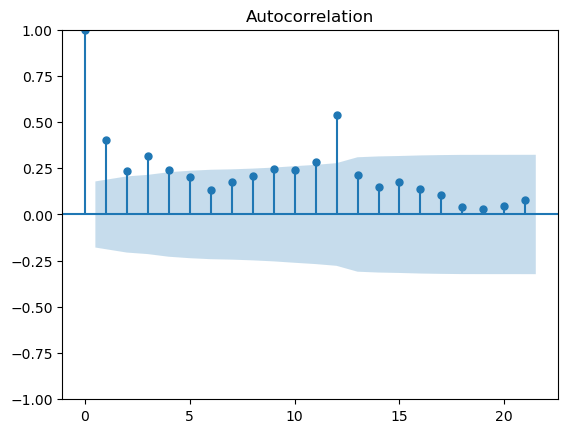

In [147]:
plot_acf(train['Rose'],alpha=0.05);

In [148]:
# SARIMA Model building to estimate best parameters
best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [149]:
SARIMA_AIC = pd.DataFrame(columns=['param','seasonal', 'AIC'])
SARIMA_AIC

,param,seasonal,AIC


In [150]:
import statsmodels.api as sm

for param in pdq:
    for param_seasonal in seasonal_pdq:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train_Rose_ts_log,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            
        results_SARIMA = SARIMA_model.fit(maxiter=1000)
        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))
        SARIMA_AIC = SARIMA_AIC.append({'param':param,'seasonal':param_seasonal ,'AIC': results_SARIMA.aic}, ignore_index=True)

SARIMA(1, 0, 1)x(1, 0, 1, 12) - AIC:-224.6106948168597
SARIMA(1, 0, 1)x(1, 0, 2, 12) - AIC:-200.36041301035968
SARIMA(1, 0, 1)x(1, 0, 3, 12) - AIC:3070.2966041726586
SARIMA(1, 0, 1)x(1, 1, 1, 12) - AIC:-203.83710664092132
SARIMA(1, 0, 1)x(1, 1, 2, 12) - AIC:-186.3329226773268
SARIMA(1, 0, 1)x(1, 1, 3, 12) - AIC:-155.19908785136099
SARIMA(1, 0, 1)x(2, 0, 1, 12) - AIC:-211.20433716463563
SARIMA(1, 0, 1)x(2, 0, 2, 12) - AIC:-207.50983278803193
SARIMA(1, 0, 1)x(2, 0, 3, 12) - AIC:-188.31082677756132
SARIMA(1, 0, 1)x(2, 1, 1, 12) - AIC:-184.06025732819563
SARIMA(1, 0, 1)x(2, 1, 2, 12) - AIC:-173.73013372007674
SARIMA(1, 0, 1)x(2, 1, 3, 12) - AIC:-156.0551450864854
SARIMA(1, 0, 1)x(3, 0, 1, 12) - AIC:-184.16873120305766
SARIMA(1, 0, 1)x(3, 0, 2, 12) - AIC:-187.7343875279532
SARIMA(1, 0, 1)x(3, 0, 3, 12) - AIC:-188.46732930768604
SARIMA(1, 0, 1)x(3, 1, 1, 12) - AIC:-143.29682368174255
SARIMA(1, 0, 1)x(3, 1, 2, 12) - AIC:-144.66885171650733
SARIMA(1, 0, 1)x(3, 1, 3, 12) - AIC:-141.731839088433

In [151]:
SARIMA_AIC.sort_values(by=['AIC'],ascending=True).head()

,param,seasonal,AIC
0,"(1, 0, 1)","(1, 0, 1, 12)",-224.610695
108,"(2, 0, 1)","(1, 0, 1, 12)",-222.981478
126,"(2, 0, 2)","(1, 0, 1, 12)",-218.826363
162,"(2, 1, 1)","(1, 0, 1, 12)",-218.233124
18,"(1, 0, 2)","(1, 0, 1, 12)",-218.182615


In [152]:
# Building SARIMA model with the best parameters
best_model = sm.tsa.statespace.SARIMAX(train_Rose_ts_log,
                                      order=(1, 0, 1),
                                      seasonal_order=(1, 0, 1, 12),
                                      enforce_stationarity=True)
best_results = best_model.fit()

In [153]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])

                                     SARIMAX Results                                      
Dep. Variable:                               Rose   No. Observations:                  120
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 122.469
Date:                            Sun, 28 Jan 2024   AIC                           -234.937
Time:                                    11:35:10   BIC                           -221.000
Sample:                                01-01-1980   HQIC                          -229.277
                                     - 12-01-1989                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9994      0.001    777.317      0.000       0.997       1.002
ma.L1         -0.9053      0.050   

In [154]:
pred_dynamic = best_results.get_prediction(start=pd.to_datetime('1990-01-01'), dynamic=True, full_results=True)

In [155]:
pred99 = best_results.get_forecast(steps=len(test), alpha=0.1)

In [156]:
# Extract the predicted and true values of our time series
Rose_sales_forecasted = pred_dynamic.predicted_mean
testCopy = test.copy()
testCopy['Rose_sales_forecasted'] = np.power(10, pred99.predicted_mean)

In [157]:
testCopy

,Year-Month,Rose,Month,Year,date,Rose_sales_forecasted
1990-01-01,1990-01,43.0,Jan,1990,1990-01-01,61.195107
1990-02-01,1990-02,69.0,Feb,1990,1990-02-01,69.199679
1990-03-01,1990-03,73.0,Mar,1990,1990-03-01,74.780532
1990-04-01,1990-04,77.0,Apr,1990,1990-04-01,67.875402
1990-05-01,1990-05,69.0,May,1990,1990-05-01,73.509815
...,...,...,...,...,...,...
1995-03-01,1995-03,45.0,Mar,1995,1995-03-01,60.452085
1995-04-01,1995-04,52.0,Apr,1995,1995-04-01,55.025600
1995-05-01,1995-05,28.0,May,1995,1995-05-01,59.460509
1995-06-01,1995-06,40.0,Jun,1995,1995-06-01,60.921075


In [158]:
#Compute the root mean square error
mse = ((testCopy['Rose'] - testCopy['Rose_sales_forecasted']) ** 2).mean()
rmse = np.sqrt(mse)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 3)))

The Root Mean Squared Error of our forecasts is 18.419


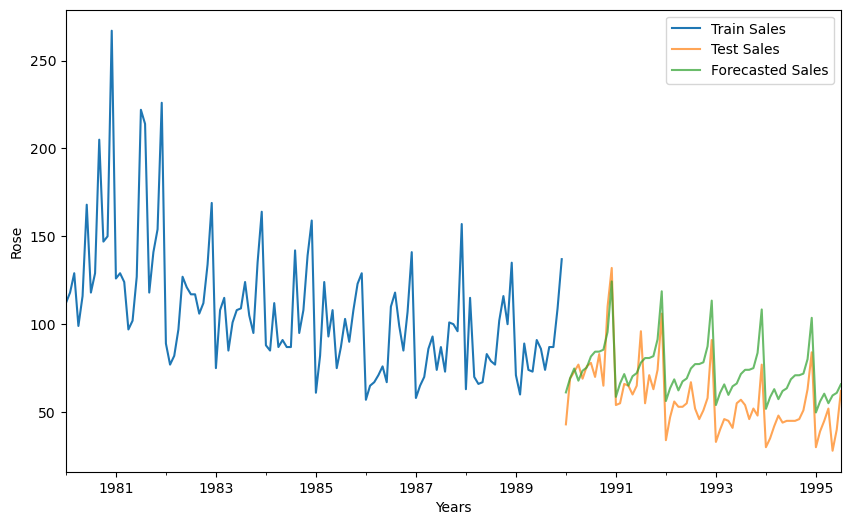

In [159]:
axis = train['Rose'].plot(label='Train Sales', figsize=(10, 6))
testCopy['Rose'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy['Rose_sales_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()
plt.close()

In [160]:
resultsDf3 = pd.DataFrame({'RMSE': rmse}
                           ,index=['Best SARIMA Model : SARIMAX(1, 0, 1)x(1, 0, 1, 12)'])

pd.concat([resultsDf,resultsDf1,resultsDf2,resultsDf3])

,RMSE
"Best AR Model : ARIMA(2,0,0)",48.891405
"Best ARMA Model : ARIMA(3,0,3)",44.794385
"Best ARIMA Model : ARIMA(3,0,3)",37.961345
"Best SARIMA Model : SARIMAX(1, 0, 1)x(1, 0, 1, 12)",18.419326


In [161]:
# Forecast sales using the best fit SARIMA model as per RMSE
# Get forecast 12 steps (1 year) ahead in future
n_steps = 12
pred_uc_99 = best_results.get_forecast(steps=12, alpha=0.01) # alpha=0.01 signifies 99% confidence interval
pred_uc_95 = best_results.get_forecast(steps=12, alpha=0.05) # alpha=0.05 95% CI

# Get confidence intervals 95% & 99% of the forecasts
pred_ci_99 = pred_uc_99.conf_int()
pred_ci_95 = pred_uc_95.conf_int()

In [162]:
n_steps = 12
idx = pd.date_range(start='1995-07-31',end='1996-07-31',freq='MS')
fc_95 = pd.DataFrame(np.column_stack([np.power(10, pred_uc_95.predicted_mean), np.power(10, pred_ci_95)]), 
                     index=idx, columns=['forecast', 'lower_ci_95', 'upper_ci_95'])
fc_99 = pd.DataFrame(np.column_stack([np.power(10, pred_ci_99)]), 
                     index=idx, columns=['lower_ci_99', 'upper_ci_99'])
fc_all = fc_95.combine_first(fc_99)
fc_all = fc_all[['forecast', 'lower_ci_95', 'upper_ci_95', 'lower_ci_99', 'upper_ci_99']] # just reordering columns
fc_all

,forecast,lower_ci_95,upper_ci_95,lower_ci_99,upper_ci_99
1995-08-01,61.195107,43.114982,86.857072,43.114982,86.857072
1995-09-01,69.199679,48.679865,98.369122,48.679865,98.369122
1995-10-01,74.780532,52.525671,106.464667,52.525671,106.464667
1995-11-01,67.875402,47.603314,96.780452,47.603314,96.780452
1995-12-01,73.509815,51.477295,104.972355,51.477295,104.972355
1996-01-01,75.365221,52.697600,107.783212,52.697600,107.783212
1996-02-01,81.620330,56.986432,116.902885,56.986432,116.902885
1996-03-01,84.363707,58.814687,121.011186,58.814687,121.011186
1996-04-01,84.389069,58.745830,121.225879,58.745830,121.225879
1996-05-01,85.494556,59.428353,122.993804,59.428353,122.993804


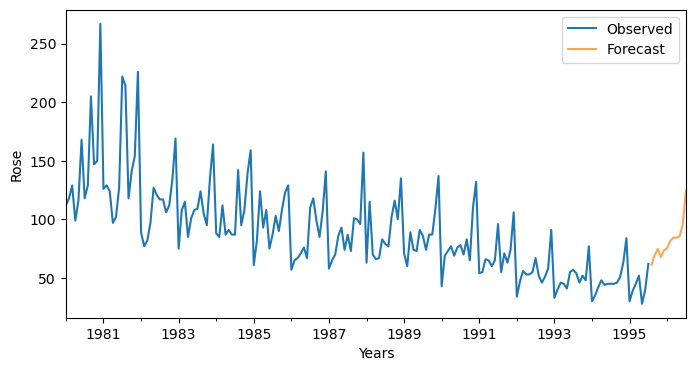

In [163]:
# plot the forecast along with the confidence band

axis = Rose_ts.plot(label='Observed', figsize=(8, 4))
fc_all['forecast'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(fc_all.index, fc_all['lower_ci_95'], fc_all['upper_ci_95'], color='k', alpha=.15)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()

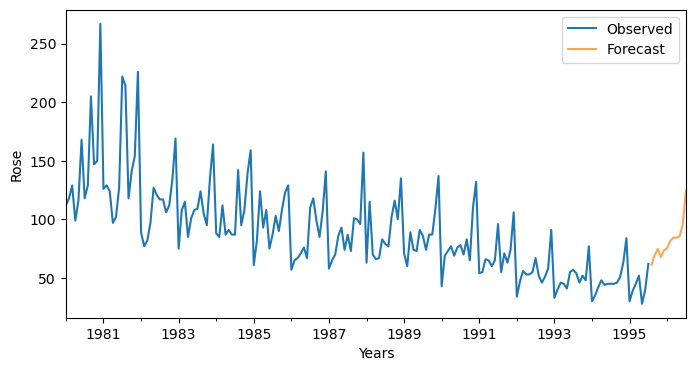

In [164]:
# plot the forecast along with the confidence band

axis = Rose_ts.plot(label='Observed', figsize=(8, 4))
fc_all['forecast'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(fc_all.index, fc_all['lower_ci_99'], fc_all['upper_ci_99'], color='k', alpha=.15)
axis.set_xlabel('Years')
axis.set_ylabel('Rose')
plt.legend(loc='best')
plt.show()

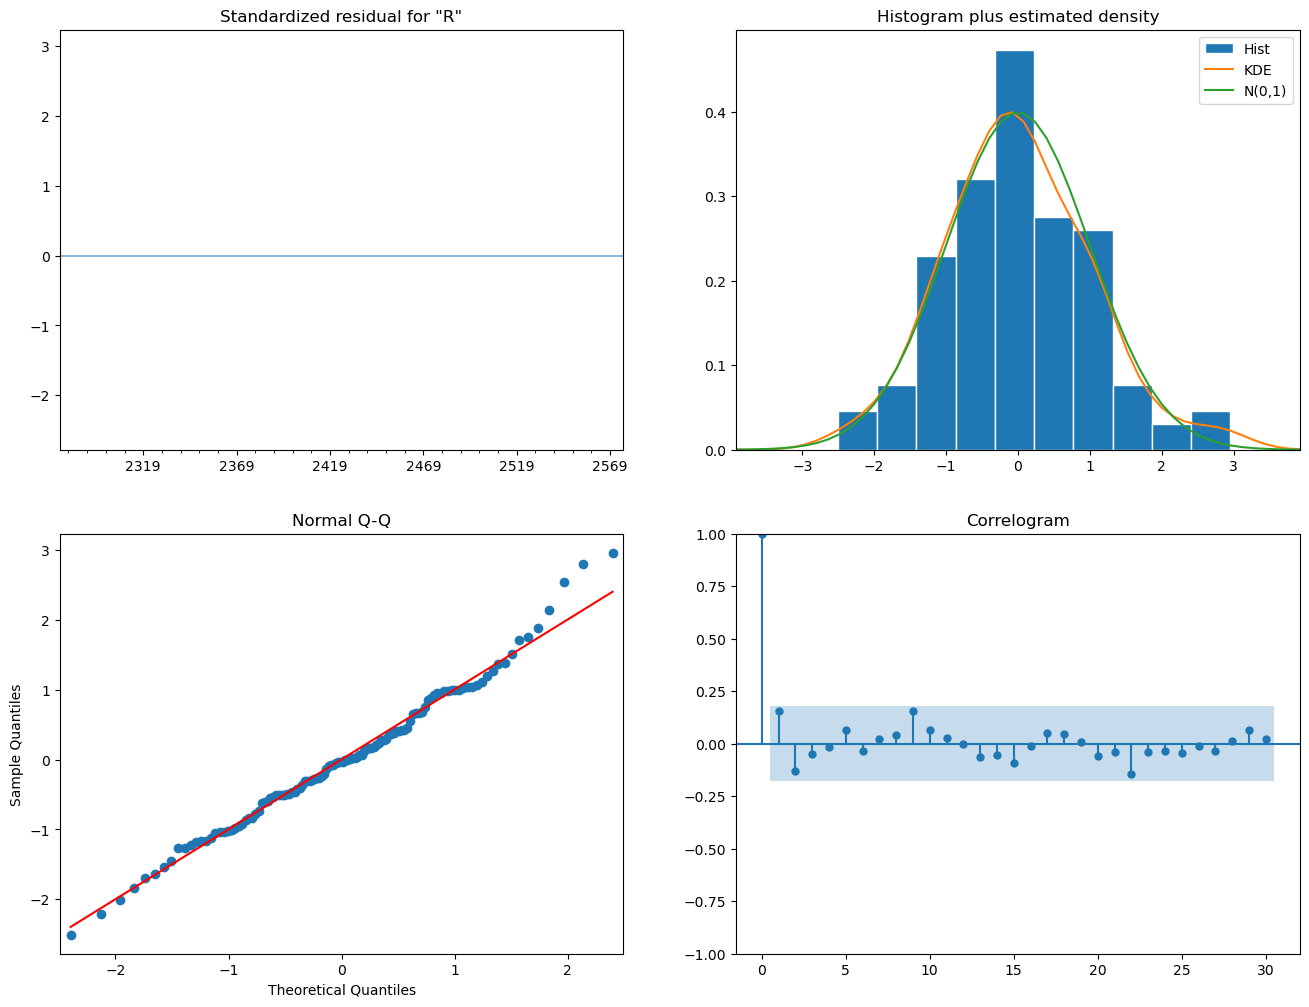

In [165]:
best_results.plot_diagnostics(lags=30, figsize=(16,12))
plt.show()